# Captain's log — Step 1：環境檢查

本步驟的目標是建立 ARIA v9.0 — The Cloud Engine 的 Python Notebook 執行環境。

本次作業將使用 Google Earth Engine 分析秀林 / 太魯閣研究區的長期 NDVI 植被時序與 Sentinel-1 SAR 時序變化。在正式連接 GEE 之前，先確認本機 Python 環境可以正常匯入基本套件，包含 NumPy、Pandas 與 Matplotlib。

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib imported successfully.")

Python version: 3.12.2 (tags/v3.12.2:6abddd9, Feb  6 2024, 21:26:36) [MSC v.1937 64 bit (AMD64)]
NumPy version: 2.3.5
Pandas version: 2.3.3
Matplotlib imported successfully.


# Captain's log — Step 2：安裝與匯入 GEE 套件

本步驟的目標是安裝並匯入 Google Earth Engine 與 geemap。

Google Earth Engine 負責雲端影像資料處理，例如 Sentinel-2 ImageCollection 篩選、雲遮罩、NDVI 計算與 Reducer 統計。geemap 則用於將 GEE 影像資料視覺化，並協助把 Earth Engine 的 FeatureCollection 轉成 Pandas DataFrame，方便後續繪製時序圖。

In [2]:
# 安裝 Google Earth Engine API 與 geemap
%pip install -q earthengine-api geemap ipyleaflet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: c:\Users\alvin\.pyenv\pyenv-win\versions\3.12.2\python.exe -m pip install --upgrade pip


In [7]:
import ee
import geemap

print("Earth Engine API imported successfully.")
print("geemap imported successfully.")

Earth Engine API imported successfully.
geemap imported successfully.


# Captain's log — Step 3：Google Earth Engine 登入與初始化

本步驟的目標是連接 Google Earth Engine 雲端運算環境。

由於本次作業需要使用 GEE 讀取 Sentinel-2 與 Sentinel-1 的 ImageCollection，並在雲端進行 NDVI、SAR 時序分析與 GeoTIFF 匯出，因此必須先完成 Earth Engine 的帳號驗證與 project 初始化。完成初始化後，會用一個簡單的測試確認 GEE 是否可以正常回傳資料。

In [8]:
import ee

# 第一次使用時需要登入 Google Earth Engine
ee.Authenticate()

True

In [11]:
import ee

PROJECT_ID = "你的-GEE-project-id"  # 例如："ee-yourname" 或 Google Cloud project ID

ee.Initialize(project='class-496807')

# 測試 GEE 是否正常運作
test_number = ee.Number(1).add(2).getInfo()
print("GEE initialized successfully.")
print("Test result:", test_number)

GEE initialized successfully.
Test result: 3


# Captain's log — Step 4：建立秀林 / 太魯閣研究區 AOI

本步驟的目標是建立本次作業指定的研究區範圍。

本次作業的研究區為花蓮秀林 / 太魯閣山區，和課堂 Demo 使用的花蓮市平原區不同。由於山區具有較高雲量、複雜地形與不同的植被變化特性，因此後續的 Sentinel-2 NDVI 時序分析與 Sentinel-1 SAR 時序分析都必須使用這個指定 AOI。

In [12]:
# 建立秀林 / 太魯閣研究區 AOI
# GEE Rectangle 座標順序為：[west, south, east, north]

TAROKO_BBOX = [
    121.34526379253053,   # west
    24.046021742135874,   # south
    121.85149217685861,   # east
    24.35767637905926     # north
]

aoi = ee.Geometry.Rectangle(TAROKO_BBOX)

print("Study area: Xiulin / Taroko")
print("BBOX:", TAROKO_BBOX)
print("AOI created successfully.")

Study area: Xiulin / Taroko
BBOX: [121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]
AOI created successfully.


In [13]:
# 顯示研究區位置

Map = geemap.Map(center=[24.20, 121.60], zoom=10)
Map.addLayer(aoi, {}, "AOI: Xiulin / Taroko")
Map

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

# Captain's log — Step 5：讀取 Sentinel-2 影像集合

本步驟的目標是從 Google Earth Engine 讀取 Sentinel-2 Level-2A 影像集合，作為後續 NDVI 時序分析的基礎資料。

本次作業需要分析 2020 年至 2026 年秀林 / 太魯閣研究區的長期植被變化，因此需要使用 ImageCollection 的方式一次篩選多年的 Sentinel-2 影像。此處會根據研究區 AOI、日期範圍與雲量比例進行篩選，並先檢查符合條件的影像數量。

In [14]:
# 讀取 Sentinel-2 Level-2A Harmonized 影像集合
# 作業指定資料集：COPERNICUS/S2_SR_HARMONIZED

s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate("2020-01-01", "2026-03-31")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 40))
)

s2_count = s2.size().getInfo()

print("Sentinel-2 ImageCollection loaded successfully.")
print("Total Sentinel-2 images:", s2_count)

Sentinel-2 ImageCollection loaded successfully.
Total Sentinel-2 images: 291


In [15]:
# 查看第一張 Sentinel-2 影像的基本資訊

first_s2 = s2.first()

print("First Sentinel-2 image ID:")
print(first_s2.get("system:index").getInfo())

print("\nAvailable band names:")
print(first_s2.bandNames().getInfo())

print("\nCloudy pixel percentage:")
print(first_s2.get("CLOUDY_PIXEL_PERCENTAGE").getInfo())

First Sentinel-2 image ID:
20200106T023059_20200106T023059_T51RUH

Available band names:
['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE']

Cloudy pixel percentage:
26.017449


# Captain's log — Step 6：Sentinel-2 雲遮罩與 NDVI 計算

本步驟的目標是建立 Sentinel-2 影像的雲遮罩與 NDVI 計算流程。

由於秀林 / 太魯閣屬於山區，容易受到雲、陰影與天氣條件影響，因此不能直接使用原始 Sentinel-2 影像計算 NDVI。本步驟使用 Sentinel-2 的 SCL 分類波段保留較可靠的像素，並排除雲與雲影等不適合分析的區域。接著利用近紅外光 B8 與紅光 B4 計算 NDVI，作為後續植被時序分析的基礎。

In [16]:
# 定義 Sentinel-2 雲遮罩與 NDVI 計算函數

def mask_and_ndvi(image):
    """
    使用 Sentinel-2 SCL 波段進行雲遮罩，並計算 NDVI。

    SCL 類別說明：
    4 = Vegetation
    5 = Bare soils
    6 = Water
    7 = Unclassified

    本作業保留 4、5、6、7 類，排除雲、雲影、雪、無資料等像素。
    """

    # 讀取 SCL 分類波段
    scl = image.select("SCL")

    # 建立有效像素遮罩
    good_pixels = (
        scl.eq(4)
        .Or(scl.eq(5))
        .Or(scl.eq(6))
        .Or(scl.eq(7))
    )

    # 套用遮罩
    masked_image = image.updateMask(good_pixels)

    # 計算 NDVI = (NIR - Red) / (NIR + Red)
    ndvi = masked_image.normalizedDifference(["B8", "B4"]).rename("NDVI")

    # 保留影像時間資訊，方便後續做時序分析
    return ndvi.copyProperties(image, ["system:time_start"])


# 將函數套用到整個 Sentinel-2 ImageCollection
ndvi_collection = s2.map(mask_and_ndvi)

print("NDVI ImageCollection created successfully.")
print("Total NDVI images:", ndvi_collection.size().getInfo())

NDVI ImageCollection created successfully.
Total NDVI images: 291


# Captain's log — Step 6 檢查：確認 NDVI 影像集合內容

本步驟的目標是確認 NDVI ImageCollection 是否正確建立。

若 NDVI 影像集合成功建立，表示每一張 Sentinel-2 影像都已完成雲遮罩與 NDVI 計算。接著檢查第一張 NDVI 影像的 band name 與時間資訊，確認後續可以用於月平均 NDVI 時序分析。

In [17]:
# 檢查第一張 NDVI 影像

first_ndvi = ndvi_collection.first()

print("First NDVI image band names:")
print(first_ndvi.bandNames().getInfo())

print("\nFirst NDVI image date:")
first_date = ee.Date(first_ndvi.get("system:time_start")).format("YYYY-MM-dd").getInfo()
print(first_date)

First NDVI image band names:
['NDVI']

First NDVI image date:
2020-01-06


# Captain's log — Step 7：建立每月 NDVI 時序表格

本步驟的目標是將 Sentinel-2 NDVI ImageCollection 轉換成每月平均 NDVI 時序資料。

由於單張 Sentinel-2 影像容易受到雲、陰影與短期天氣條件影響，因此本步驟不直接使用單景影像，而是以「每個月」為單位，先對該月份的 NDVI 影像做 median composite，再計算整個秀林 / 太魯閣 AOI 的平均 NDVI。這樣可以建立 2020 年至 2026 年的月尺度植被變化時間序列，作為後續判斷季節變化與地震影響的基礎。

In [18]:
# 建立 2020-01 到 2026-03 的每月 NDVI 統計表

start_date = ee.Date("2020-01-01")
end_date = ee.Date("2026-04-01")  # 結束到 2026-03，因此 end date 設為 2026-04-01

# 計算總月份數
n_months = end_date.difference(start_date, "month").round()
months = ee.List.sequence(0, n_months.subtract(1))


def monthly_ndvi_feature(m):
    """
    對每一個月份：
    1. 篩選該月份的 NDVI 影像
    2. 做 median composite
    3. 計算 AOI 內平均 NDVI
    4. 回傳日期、NDVI 平均值與影像張數
    """

    m = ee.Number(m)
    month_start = start_date.advance(m, "month")
    month_end = month_start.advance(1, "month")

    # 篩選該月份的 NDVI 影像
    monthly_ic = ndvi_collection.filterDate(month_start, month_end)

    # 使用 median composite 降低雲、陰影與異常值影響
    monthly_img = monthly_ic.median()

    # 計算 AOI 內平均 NDVI
    mean_ndvi = monthly_img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=30,
        maxPixels=1e9
    ).get("NDVI")

    return ee.Feature(None, {
        "date": month_start.format("YYYY-MM"),
        "NDVI": mean_ndvi,
        "image_count": monthly_ic.size()
    })


# 將每個月份轉成 FeatureCollection
monthly_fc = ee.FeatureCollection(months.map(monthly_ndvi_feature))

print("Monthly NDVI FeatureCollection created successfully.")

Monthly NDVI FeatureCollection created successfully.


# Captain's log — Step 7 修正：逐月計算 NDVI，避免同時聚合過多

原本的 monthly FeatureCollection 方法會在 GEE 端同時執行多個 reduceRegion 統計，因此可能觸發 Too many concurrent aggregations 錯誤。

本步驟改用較穩定的方式：由 Python 逐月向 GEE 請求資料。每次只處理一個月份的 NDVI median composite，並計算該月份 AOI 內的平均 NDVI。雖然速度較慢，但可以避免一次送出過多聚合運算，較適合在本機 VS / Jupyter 環境中執行。

In [20]:
# Step 7 修正版：逐月計算 NDVI，避免 GEE 同時執行太多 reduceRegion

import pandas as pd
import numpy as np

monthly_records = []

# 2020-01 到 2026-03，共 75 個月份
date_range = pd.date_range(start="2020-01-01", end="2026-03-01", freq="MS")

for month_start_pd in date_range:
    month_end_pd = month_start_pd + pd.DateOffset(months=1)

    month_start = month_start_pd.strftime("%Y-%m-%d")
    month_end = month_end_pd.strftime("%Y-%m-%d")
    month_label = month_start_pd.strftime("%Y-%m")

    print(f"Processing {month_label} ...")

    # 篩選該月份 NDVI 影像
    monthly_ic = ndvi_collection.filterDate(month_start, month_end)

    # 計算該月份影像張數
    image_count = monthly_ic.size().getInfo()

    if image_count == 0:
        mean_ndvi_value = np.nan
    else:
        # 該月份 median composite
        monthly_img = monthly_ic.median()

        # 計算 AOI 內平均 NDVI
        mean_ndvi = monthly_img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=30,
            maxPixels=1e9,
            bestEffort=True
        ).get("NDVI")

        mean_ndvi_value = mean_ndvi.getInfo()

    monthly_records.append({
        "date": month_label,
        "NDVI": mean_ndvi_value,
        "image_count": image_count
    })

print("Monthly NDVI calculation finished.")

Processing 2020-01 ...
Processing 2020-02 ...
Processing 2020-03 ...
Processing 2020-04 ...
Processing 2020-05 ...
Processing 2020-06 ...
Processing 2020-07 ...
Processing 2020-08 ...
Processing 2020-09 ...
Processing 2020-10 ...
Processing 2020-11 ...
Processing 2020-12 ...
Processing 2021-01 ...
Processing 2021-02 ...
Processing 2021-03 ...
Processing 2021-04 ...
Processing 2021-05 ...
Processing 2021-06 ...
Processing 2021-07 ...
Processing 2021-08 ...
Processing 2021-09 ...
Processing 2021-10 ...
Processing 2021-11 ...
Processing 2021-12 ...
Processing 2022-01 ...
Processing 2022-02 ...
Processing 2022-03 ...
Processing 2022-04 ...
Processing 2022-05 ...
Processing 2022-06 ...
Processing 2022-07 ...
Processing 2022-08 ...
Processing 2022-09 ...
Processing 2022-10 ...
Processing 2022-11 ...
Processing 2022-12 ...
Processing 2023-01 ...
Processing 2023-02 ...
Processing 2023-03 ...
Processing 2023-04 ...
Processing 2023-05 ...
Processing 2023-06 ...
Processing 2023-07 ...
Processing 

In [24]:
# 將逐月計算結果轉成 Pandas DataFrame

monthly_df = pd.DataFrame(monthly_records)

monthly_df["date"] = pd.to_datetime(monthly_df["date"])
monthly_df["NDVI"] = pd.to_numeric(monthly_df["NDVI"], errors="coerce")
monthly_df["image_count"] = pd.to_numeric(monthly_df["image_count"], errors="coerce")

monthly_df = monthly_df.sort_values("date").reset_index(drop=True)

print("Monthly NDVI DataFrame created successfully.")
print("Number of monthly records:", len(monthly_df))

monthly_df.head(10)

Monthly NDVI DataFrame created successfully.
Number of monthly records: 75


,date,NDVI,image_count
0,2020-01-01,0.459518,8
1,2020-02-01,0.461060,4
2,2020-03-01,0.430335,5
3,2020-04-01,0.499299,2
4,2020-05-01,0.438349,4
5,2020-06-01,0.550458,5
6,2020-07-01,0.529235,5
7,2020-08-01,0.511868,4
8,2020-09-01,0.492768,5
9,2020-10-01,0.481987,3


In [25]:
# 檢查是否有 NDVI 缺值月份

missing_months = monthly_df[monthly_df["NDVI"].isna()]

print("Number of missing NDVI months:", len(missing_months))

if len(missing_months) > 0:
    print("Missing months:")
    display(missing_months[["date", "NDVI", "image_count"]])
else:
    print("No missing NDVI months.")

Number of missing NDVI months: 3
Missing months:


,date,NDVI,image_count
24,2022-01-01,NaN,0
25,2022-02-01,NaN,0
52,2024-05-01,NaN,0


# Captain's log — Step 8：繪製 NDVI 月時序圖

本步驟的目標是將 2020-01 到 2026-03 的月平均 NDVI 結果繪製成時間序列圖。

此圖可以用來觀察秀林 / 太魯閣研究區的長期植被變化，包括季節性起伏、地震前後 NDVI 是否出現下降，以及部分月份是否因為雲量過高或有效像素不足而產生缺值。圖中會加入 2024/04/03 花蓮地震的垂直標記線，方便比較地震前後的 NDVI 變化。

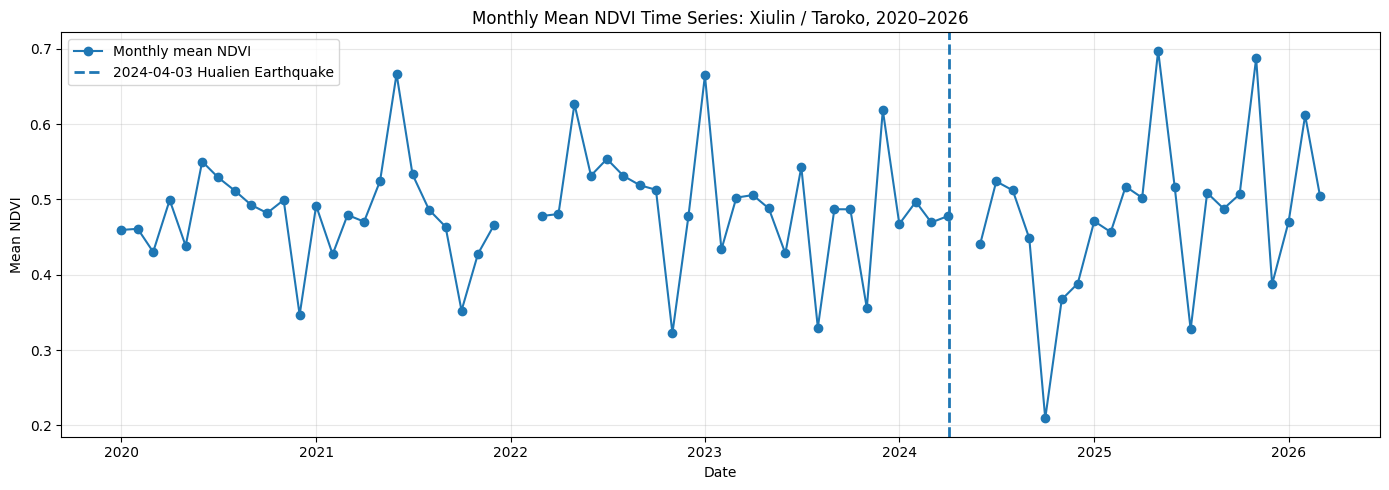

In [26]:
# 繪製 2020-2026 月平均 NDVI 時序圖

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_df["date"],
    monthly_df["NDVI"],
    marker="o",
    linewidth=1.5,
    label="Monthly mean NDVI"
)

# 標出 2024/04/03 花蓮地震
earthquake_date = pd.to_datetime("2024-04-03")
plt.axvline(
    earthquake_date,
    linestyle="--",
    linewidth=2,
    label="2024-04-03 Hualien Earthquake"
)

plt.title("Monthly Mean NDVI Time Series: Xiulin / Taroko, 2020–2026")
plt.xlabel("Date")
plt.ylabel("Mean NDVI")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

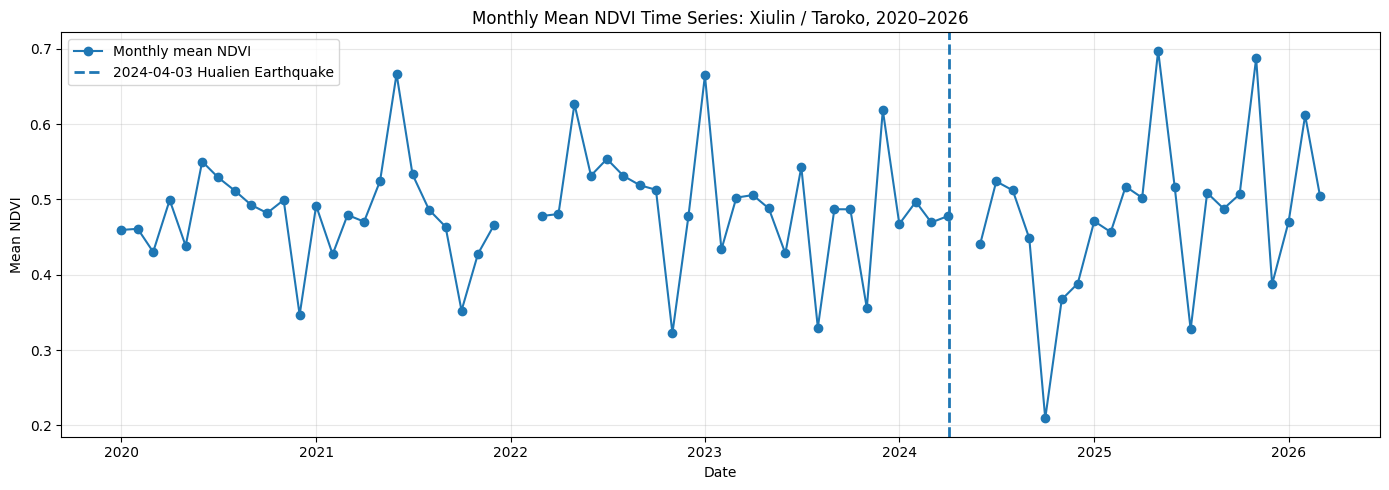

Saved figure: task1_ndvi_timeseries.png


In [27]:
# 儲存 NDVI 時序圖

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_df["date"],
    monthly_df["NDVI"],
    marker="o",
    linewidth=1.5,
    label="Monthly mean NDVI"
)

earthquake_date = pd.to_datetime("2024-04-03")
plt.axvline(
    earthquake_date,
    linestyle="--",
    linewidth=2,
    label="2024-04-03 Hualien Earthquake"
)

plt.title("Monthly Mean NDVI Time Series: Xiulin / Taroko, 2020–2026")
plt.xlabel("Date")
plt.ylabel("Mean NDVI")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("task1_ndvi_timeseries.png", dpi=300)
plt.show()

print("Saved figure: task1_ndvi_timeseries.png")

# Captain's log — Step 9：計算 NDVI 時序輔助統計值

本步驟的目標是從月平均 NDVI 表格中計算幾個輔助統計值，協助解讀 Task 1 的時序圖。

除了視覺化觀察 NDVI 折線圖之外，本步驟進一步比較地震前、地震後短期與地震後較長期的平均 NDVI。這些數值可以用來判斷 2024/04/03 花蓮地震後，秀林 / 太魯閣研究區的植被狀態是否有下降，以及後續是否出現恢復或持續波動的現象。

In [28]:
# 計算 Task 1 輔助統計值

# 定義幾個分析時段
pre_eq_period = monthly_df[
    (monthly_df["date"] >= "2023-01-01") &
    (monthly_df["date"] <= "2024-03-31")
]

post_eq_short_period = monthly_df[
    (monthly_df["date"] >= "2024-04-01") &
    (monthly_df["date"] <= "2024-09-30")
]

post_eq_long_period = monthly_df[
    (monthly_df["date"] >= "2024-10-01") &
    (monthly_df["date"] <= "2026-03-31")
]

# 計算平均 NDVI
pre_eq_mean = pre_eq_period["NDVI"].mean()
post_eq_short_mean = post_eq_short_period["NDVI"].mean()
post_eq_long_mean = post_eq_long_period["NDVI"].mean()

# 找出 NDVI 最低與最高月份
min_ndvi_row = monthly_df.loc[monthly_df["NDVI"].idxmin()]
max_ndvi_row = monthly_df.loc[monthly_df["NDVI"].idxmax()]

# 缺值月份數
missing_count = monthly_df["NDVI"].isna().sum()

print("Task 1 NDVI Summary")
print("-------------------")
print(f"Pre-earthquake mean NDVI (2023-01 to 2024-03): {pre_eq_mean:.3f}")
print(f"Short post-earthquake mean NDVI (2024-04 to 2024-09): {post_eq_short_mean:.3f}")
print(f"Long post-earthquake mean NDVI (2024-10 to 2026-03): {post_eq_long_mean:.3f}")
print()
print(f"Minimum NDVI month: {min_ndvi_row['date'].strftime('%Y-%m')}, NDVI = {min_ndvi_row['NDVI']:.3f}")
print(f"Maximum NDVI month: {max_ndvi_row['date'].strftime('%Y-%m')}, NDVI = {max_ndvi_row['NDVI']:.3f}")
print()
print(f"Number of missing NDVI months: {missing_count}")

Task 1 NDVI Summary
-------------------
Pre-earthquake mean NDVI (2023-01 to 2024-03): 0.485
Short post-earthquake mean NDVI (2024-04 to 2024-09): 0.481
Long post-earthquake mean NDVI (2024-10 to 2026-03): 0.479

Minimum NDVI month: 2024-10, NDVI = 0.209
Maximum NDVI month: 2025-05, NDVI = 0.698

Number of missing NDVI months: 3


# Captain's log — Step 10：Task 1 NDVI 時序分析

本步驟的目標是根據 2020–2026 年的月平均 NDVI 時序圖與統計結果，撰寫 Task 1 的分析說明。

從 NDVI 時序圖可以觀察秀林 / 太魯閣研究區的長期植被變化，並比較 2024/04/03 花蓮地震前後的平均 NDVI 是否出現明顯差異。此外，也需要說明缺值月份的可能原因，因為山區常受到雲、霧與降雨影響，使部分月份的 Sentinel-2 有效觀測不足。

## Task 1 分析

2020–2026 年的月平均 NDVI 時序顯示，秀林 / 太魯閣研究區的植被狀態具有明顯的時間波動，可能受到季節、降雨、雲量與山區地形影響。地震前 2023-01 至 2024-03 的平均 NDVI 為 0.485，地震後短期 2024-04 至 2024-09 的平均 NDVI 為 0.481，顯示整個 AOI 平均值只有小幅下降，因此地震影響在全區平均尺度上並不非常明顯。不過，2024-10 的 NDVI 降至 0.209，是整段時序中的最低值，可能與地震後局部崩塌、裸露地增加、有效像素不足或季節性影響有關。本時序共有 3 個月份出現 NDVI 缺值，推測是因為太魯閣山區雲量高、降雨頻繁，使 Sentinel-2 影像經過雲遮罩後可用像素不足。

# Captain's log — Step 11：建立三期 NDVI Median Composite

本步驟的目標是建立三個時期的 NDVI 中值合成影像，分別代表震前、震後短期，以及堰塞湖事件後的植被狀態。

相較於只使用單張影像，median composite 可以整合一段時間內的多張 Sentinel-2 NDVI 影像，降低雲、陰影、短期天氣與單景影像雜訊的影響。本步驟建立的三期 composite 將作為後續 ΔNDVI 變遷偵測的基礎。

In [29]:
# Task 2：建立三期 NDVI median composite

# 震前：2023-01 至 2024-03
pre_eq = (
    ndvi_collection
    .filterDate("2023-01-01", "2024-03-31")
    .median()
    .rename("NDVI")
)

# 震後短期：2024-04 至 2024-09
post_eq = (
    ndvi_collection
    .filterDate("2024-04-01", "2024-09-30")
    .median()
    .rename("NDVI")
)

# 堰塞湖事件後：2025-10 至 2026-03
post_dam = (
    ndvi_collection
    .filterDate("2025-10-01", "2026-03-31")
    .median()
    .rename("NDVI")
)

print("Three NDVI median composites created successfully.")
print("pre_eq band names:", pre_eq.bandNames().getInfo())
print("post_eq band names:", post_eq.bandNames().getInfo())
print("post_dam band names:", post_dam.bandNames().getInfo())

Three NDVI median composites created successfully.
pre_eq band names: ['NDVI']
post_eq band names: ['NDVI']
post_dam band names: ['NDVI']


# Captain's log — Step 11 檢查：統計三期可用影像數量

本步驟的目標是檢查三個 composite 時段各自使用了多少張 Sentinel-2 NDVI 影像。

影像數量會影響 median composite 的穩定性。若某一時段影像數量較少，代表該時期可能受雲量或篩選條件影響較大，後續解讀 ΔNDVI 時需要更謹慎。

In [30]:
# 統計三個時期各自包含多少張 NDVI 影像

pre_eq_count = ndvi_collection.filterDate("2023-01-01", "2024-03-31").size().getInfo()
post_eq_count = ndvi_collection.filterDate("2024-04-01", "2024-09-30").size().getInfo()
post_dam_count = ndvi_collection.filterDate("2025-10-01", "2026-03-31").size().getInfo()

print("Number of Sentinel-2 NDVI images used:")
print(f"Pre-earthquake period  (2023-01 to 2024-03): {pre_eq_count}")
print(f"Post-earthquake period (2024-04 to 2024-09): {post_eq_count}")
print(f"Post-dam period        (2025-10 to 2026-03): {post_dam_count}")

Number of Sentinel-2 NDVI images used:
Pre-earthquake period  (2023-01 to 2024-03): 49
Post-earthquake period (2024-04 to 2024-09): 28
Post-dam period        (2025-10 to 2026-03): 24


# Captain's log — Step 12：計算三組 ΔNDVI 變遷影像

本步驟的目標是利用三期 NDVI median composite 計算植被變化量，也就是 ΔNDVI。

ΔNDVI 的概念是用後期 NDVI 減去前期 NDVI。若 ΔNDVI 為負值，代表該區域的 NDVI 下降，可能表示植被損失、山崩、裸露地增加或災害造成的地表擾動。若 ΔNDVI 為正值，則可能代表植被恢復或綠度增加。本步驟會建立三組差值影像：地震影響、堰塞湖後變化，以及整體累積變化。

In [31]:
# Task 2：計算三組 ΔNDVI

# 地震影響：震後短期 - 震前
delta_eq = post_eq.subtract(pre_eq).rename("delta_NDVI_eq")

# 堰塞湖後變化：堰塞湖後 - 震後短期
delta_dam = post_dam.subtract(post_eq).rename("delta_NDVI_dam")

# 整體累積變化：堰塞湖後 - 震前
delta_total = post_dam.subtract(pre_eq).rename("delta_NDVI_total")

print("Delta NDVI images created successfully.")
print("delta_eq band names:", delta_eq.bandNames().getInfo())
print("delta_dam band names:", delta_dam.bandNames().getInfo())
print("delta_total band names:", delta_total.bandNames().getInfo())

Delta NDVI images created successfully.
delta_eq band names: ['delta_NDVI_eq']
delta_dam band names: ['delta_NDVI_dam']
delta_total band names: ['delta_NDVI_total']


# Captain's log — Step 12 檢查：計算三組 ΔNDVI 的 AOI 平均值

本步驟的目標是計算三組 ΔNDVI 在整個研究區內的平均值，作為後續解讀變遷圖的輔助資訊。

整體平均 ΔNDVI 可以初步判斷研究區在不同階段是否呈現植被下降或恢復趨勢。不過，由於災害損害通常集中在局部山坡或河谷區域，AOI 平均值可能會稀釋局部強烈變化，因此後續仍需要搭配 ΔNDVI 地圖與受損面積統計一起判讀。

In [32]:
# 計算三組 ΔNDVI 在 AOI 內的平均值

def mean_over_aoi(image, band_name):
    result = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    )
    return result.get(band_name).getInfo()


mean_delta_eq = mean_over_aoi(delta_eq, "delta_NDVI_eq")
mean_delta_dam = mean_over_aoi(delta_dam, "delta_NDVI_dam")
mean_delta_total = mean_over_aoi(delta_total, "delta_NDVI_total")

print("Mean ΔNDVI over AOI:")
print(f"Earthquake impact ΔNDVI      : {mean_delta_eq:.4f}")
print(f"Post-dam / recovery ΔNDVI    : {mean_delta_dam:.4f}")
print(f"Total accumulated ΔNDVI      : {mean_delta_total:.4f}")

Mean ΔNDVI over AOI:
Earthquake impact ΔNDVI      : 0.0027
Post-dam / recovery ΔNDVI    : -0.0132
Total accumulated ΔNDVI      : -0.0094


# Captain's log — Step 13：視覺化三期 NDVI Composite 與 ΔNDVI 地圖

本步驟的目標是將三期 NDVI median composite 與三組 ΔNDVI 變遷影像顯示在互動式地圖上。

前一步計算的 AOI 平均 ΔNDVI 只能代表整個研究區的整體趨勢，但災害造成的植被損失通常集中在局部山坡、河谷或崩塌區，因此必須透過地圖觀察空間分布。本步驟會用綠色系呈現 NDVI composite，並用紅白藍發散色階呈現 ΔNDVI，其中紅色代表植被下降，藍色代表植被增加。

In [33]:
# Task 2：顯示三期 NDVI composite 與三張 ΔNDVI map

# NDVI 視覺化參數
ndvi_vis = {
    "min": 0,
    "max": 0.8,
    "palette": ["brown", "yellow", "green", "darkgreen"]
}

# ΔNDVI 視覺化參數
# 紅色：植被下降；白色：變化小；藍色：植被增加
delta_vis = {
    "min": -0.4,
    "max": 0.4,
    "palette": ["red", "white", "blue"]
}

# 建立互動式地圖
Map = geemap.Map(center=[24.20, 121.60], zoom=10)

# 加入研究區
Map.addLayer(aoi, {}, "AOI: Xiulin / Taroko")

# 加入三期 NDVI composite
Map.addLayer(pre_eq.clip(aoi), ndvi_vis, "NDVI Pre-earthquake: 2023-01 to 2024-03")
Map.addLayer(post_eq.clip(aoi), ndvi_vis, "NDVI Post-earthquake: 2024-04 to 2024-09")
Map.addLayer(post_dam.clip(aoi), ndvi_vis, "NDVI Post-dam: 2025-10 to 2026-03")

# 加入三組 ΔNDVI
Map.addLayer(delta_eq.clip(aoi), delta_vis, "ΔNDVI Earthquake impact")
Map.addLayer(delta_dam.clip(aoi), delta_vis, "ΔNDVI Post-dam / recovery")
Map.addLayer(delta_total.clip(aoi), delta_vis, "ΔNDVI Total accumulated change")

Map

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

紅色區域：NDVI 下降，可能是植被損失、裸露地或崩塌

白色區域：變化不大

藍色區域：NDVI 增加，可能是恢復或季節性綠度增加

# Captain's log — Step 14：計算 ΔNDVI 顯著下降區域面積

本步驟的目標是計算三組 ΔNDVI 影像中，NDVI 顯著下降區域的面積。

此處使用 ΔNDVI < -0.15 作為植被明顯損失的判斷門檻。若某區域的 NDVI 下降超過此門檻，可能代表植被受損、山崩、裸露地增加或其他災害造成的地表擾動。本步驟會分別計算地震影響、堰塞湖後變化，以及整體累積變化三個階段的顯著下降面積，並將結果轉換為公頃。

In [34]:
# Task 2：計算 ΔNDVI < -0.15 的面積，單位為 hectares

def damaged_area_ha(delta_img, band_name, threshold=-0.15):
    """
    計算 ΔNDVI 小於指定門檻值的面積。

    參數：
    delta_img: GEE Image，ΔNDVI 影像
    band_name: str，ΔNDVI band 名稱
    threshold: float，植被顯著下降門檻，預設為 -0.15

    回傳：
    面積，單位為 hectares
    """

    # 建立受損區遮罩
    damage_mask = delta_img.select(band_name).lt(threshold)

    # 將符合條件的像素轉成面積
    area_image = damage_mask.multiply(ee.Image.pixelArea())

    # 統計 AOI 內總面積，單位為平方公尺
    area_m2 = area_image.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=10,
        maxPixels=1e9,
        bestEffort=True
    ).get(band_name)

    # 平方公尺轉公頃
    area_ha = ee.Number(area_m2).divide(10000)

    return area_ha.getInfo()


area_eq_ha = damaged_area_ha(delta_eq, "delta_NDVI_eq", threshold=-0.15)
area_dam_ha = damaged_area_ha(delta_dam, "delta_NDVI_dam", threshold=-0.15)
area_total_ha = damaged_area_ha(delta_total, "delta_NDVI_total", threshold=-0.15)

print("Area with ΔNDVI < -0.15")
print("-----------------------")
print(f"Earthquake impact area      : {area_eq_ha:.2f} ha")
print(f"Post-dam / recovery area    : {area_dam_ha:.2f} ha")
print(f"Total accumulated loss area : {area_total_ha:.2f} ha")

Area with ΔNDVI < -0.15
-----------------------
Earthquake impact area      : 7740.15 ha
Post-dam / recovery area    : 6257.68 ha
Total accumulated loss area : 6839.04 ha


In [35]:
# 將受損面積結果整理成表格

damage_area_df = pd.DataFrame({
    "phase": [
        "Earthquake impact: post_eq - pre_eq",
        "Post-dam / recovery: post_dam - post_eq",
        "Total accumulated change: post_dam - pre_eq"
    ],
    "threshold": ["ΔNDVI < -0.15"] * 3,
    "area_ha": [
        area_eq_ha,
        area_dam_ha,
        area_total_ha
    ]
})

damage_area_df

,phase,threshold,area_ha
0,Earthquake impact: post_eq - pre_eq,ΔNDVI < -0.15,7740.145333
1,Post-dam / recovery: post_dam - post_eq,ΔNDVI < -0.15,6257.677281
2,Total accumulated change: post_dam - pre_eq,ΔNDVI < -0.15,6839.039621


# Captain's log — Step 15：建立 ΔNDVI 顯著下降區域遮罩圖

本步驟的目標是將 ΔNDVI < -0.15 的區域轉換成遮罩圖層，並顯示在互動式地圖上。

前一步已經計算三個階段的顯著 NDVI 下降面積，但只有面積數值還無法判斷這些變化發生在哪裡。因此本步驟將地震影響、堰塞湖後變化與整體累積變化三個階段的受損區域分別製作成 map layer。這有助於觀察植被損失是否集中在山坡、河谷或特定災害區域。

In [36]:
# Task 2：建立 ΔNDVI < -0.15 的受損區遮罩

threshold = -0.15

loss_eq = delta_eq.select("delta_NDVI_eq").lt(threshold).selfMask()
loss_dam = delta_dam.select("delta_NDVI_dam").lt(threshold).selfMask()
loss_total = delta_total.select("delta_NDVI_total").lt(threshold).selfMask()

print("Loss masks created successfully.")

Loss masks created successfully.


# Captain's log — Step 15 檢查：顯示三階段受損區遮罩

本步驟的目標是將三個階段的 NDVI 顯著下降區域顯示在地圖上。

地圖中會同時放入 ΔNDVI 變遷影像與 ΔNDVI < -0.15 的遮罩圖層。紅色系 ΔNDVI 圖層可顯示植被下降程度，而遮罩圖層則直接標出超過門檻值的顯著受損區域，方便後續截圖與撰寫 Task 2 分析。

In [37]:
# 顯示三階段 ΔNDVI 與受損區遮罩

Map = geemap.Map(center=[24.20, 121.60], zoom=10)

# 加入 AOI
Map.addLayer(aoi, {}, "AOI: Xiulin / Taroko")

# ΔNDVI 發散色階
delta_vis = {
    "min": -0.4,
    "max": 0.4,
    "palette": ["red", "white", "blue"]
}

# 加入三張 ΔNDVI map
Map.addLayer(delta_eq.clip(aoi), delta_vis, "ΔNDVI Earthquake impact")
Map.addLayer(delta_dam.clip(aoi), delta_vis, "ΔNDVI Post-dam / recovery")
Map.addLayer(delta_total.clip(aoi), delta_vis, "ΔNDVI Total accumulated change")

# 加入 ΔNDVI < -0.15 的遮罩圖層
Map.addLayer(loss_eq.clip(aoi), {"palette": ["orange"]}, "Loss mask: Earthquake impact")
Map.addLayer(loss_dam.clip(aoi), {"palette": ["purple"]}, "Loss mask: Post-dam / recovery")
Map.addLayer(loss_total.clip(aoi), {"palette": ["black"]}, "Loss mask: Total accumulated loss")

Map

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

# Captain's log — Step 16：Task 2 變遷偵測分析與方法比較

本步驟的目標是根據三期 NDVI median composite、三組 ΔNDVI 變遷影像，以及 ΔNDVI < -0.15 的面積統計結果，撰寫 Task 2 的分析說明。

前面已經完成震前、震後短期與堰塞湖事件後三個階段的 NDVI composite，並計算地震影響、堰塞湖後變化與整體累積變化。接下來需要將這些結果轉換成文字解讀，說明哪些階段出現較明顯的植被下降，並比較 W13 使用多時期 median composite 的方法，如何改善 W9 只使用兩張單景影像進行變遷偵測的限制。

## Task 2 分析：三期 NDVI Composite 與 ΔNDVI 變遷偵測

本次分析使用三個時期的 Sentinel-2 NDVI median composite，分別代表震前、震後短期，以及堰塞湖事件後的植被狀態。根據 ΔNDVI < -0.15 的門檻統計，地震影響階段的顯著 NDVI 下降面積約為 7740.15 ha，堰塞湖後變化階段約為 6257.68 ha，整體累積下降面積約為 6839.04 ha。這表示研究區內確實存在大範圍 NDVI 下降區域，可能與地震後山坡崩塌、裸露地增加、河谷地形擾動或後續災害事件有關。

從 AOI 平均 ΔNDVI 來看，地震影響的平均值為 0.0027，堰塞湖後變化為 -0.0132，整體累積變化為 -0.0094，整體平均變化幅度不大。這代表若只看整個研究區平均值，災害訊號會被大面積未變化森林稀釋。因此，ΔNDVI 空間分布圖與顯著下降區域遮罩，比單純平均值更適合用來判斷局部災害影響。

相較於 W9 使用兩張單景影像進行變遷偵測，W13 的 median composite 方法較穩定。W9 的結果容易受到任一張影像的雲、陰影、季節差異或感測雜訊影響；而 W13 在每個時期整合多張 Sentinel-2 影像後取中值，可以降低單景異常值造成的誤判。此外，三期比較也能將地震後立即影響、後續堰塞湖事件與長期累積變化分開觀察，使災害時間線的判讀更完整。

# Captain's log — Step 17：讀取 Sentinel-1 SAR GRD 影像集合

本步驟的目標是讀取 Sentinel-1 SAR GRD 影像集合，作為 Task 3 雷達時序分析的基礎資料。

Sentinel-1 SAR 與 Sentinel-2 光學影像不同，SAR 主動發射微波訊號，因此較不容易受到雲層影響，適合用來輔助觀察山區地表變化。本步驟會篩選秀林 / 太魯閣研究區 2022-01-01 至 2026-03-31 的 Sentinel-1 GRD 影像，並限制為 IW 模式、descending orbit 與 VV polarization，以建立後續 VV backscatter 時序分析資料集。

In [39]:
# Task 3：讀取 Sentinel-1 GRD 影像集合

s1 = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(aoi)
    .filterDate("2022-01-01", "2026-03-31")
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.eq("orbitProperties_pass", "DESCENDING"))
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
    .select("VV")
)

s1_count = s1.size().getInfo()

print("Sentinel-1 ImageCollection loaded successfully.")
print("Total Sentinel-1 images:", s1_count)

Sentinel-1 ImageCollection loaded successfully.
Total Sentinel-1 images: 146


In [40]:
# 檢查第一張 Sentinel-1 影像資訊

first_s1 = s1.first()

print("First Sentinel-1 image ID:")
print(first_s1.get("system:index").getInfo())

print("\nAvailable band names:")
print(first_s1.bandNames().getInfo())

print("\nFirst Sentinel-1 image date:")
first_s1_date = ee.Date(first_s1.get("system:time_start")).format("YYYY-MM-dd").getInfo()
print(first_s1_date)

First Sentinel-1 image ID:
S1A_IW_GRDH_1SDV_20220103T215227_20220103T215256_041302_04E8DE_1CBF

Available band names:
['VV']

First Sentinel-1 image date:
2022-01-03


# Captain's log — Step 18：建立 Sentinel-1 VV Backscatter 時序表格

本步驟的目標是將 Sentinel-1 SAR 影像集合轉換成 VV backscatter 時序資料。

Sentinel-1 的 VV backscatter 可以反映地表粗糙度、含水量、裸露地與植被結構等變化。由於 Task 3 需要觀察地震前後 SAR 訊號是否改變，因此本步驟會逐張影像計算秀林 / 太魯閣 AOI 內的平均 VV 值，並建立包含日期與 VV 平均值的 Pandas DataFrame，作為後續繪製 SAR 時序圖的基礎。

In [41]:
# Task 3：逐張計算 Sentinel-1 VV 平均值，建立時序資料

import pandas as pd
import numpy as np

s1_count = s1.size().getInfo()
s1_list = s1.toList(s1_count)

s1_records = []

for i in range(s1_count):
    image = ee.Image(s1_list.get(i))

    # 取得影像日期
    date = ee.Date(image.get("system:time_start")).format("YYYY-MM-dd").getInfo()

    print(f"Processing Sentinel-1 image {i + 1}/{s1_count}: {date}")

    try:
        # 計算 AOI 內平均 VV backscatter
        mean_vv = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=30,
            maxPixels=1e9,
            bestEffort=True
        ).get("VV")

        mean_vv_value = mean_vv.getInfo()

    except Exception as e:
        print(f"Warning: failed to process {date}")
        print(e)
        mean_vv_value = np.nan

    s1_records.append({
        "date": date,
        "VV": mean_vv_value
    })

print("Sentinel-1 VV time series calculation finished.")

Processing Sentinel-1 image 1/146: 2022-01-03
Processing Sentinel-1 image 2/146: 2022-02-08
Processing Sentinel-1 image 3/146: 2022-07-26
Processing Sentinel-1 image 4/146: 2022-08-07
Processing Sentinel-1 image 5/146: 2022-08-19
Processing Sentinel-1 image 6/146: 2022-08-31
Processing Sentinel-1 image 7/146: 2022-09-12
Processing Sentinel-1 image 8/146: 2022-09-24
Processing Sentinel-1 image 9/146: 2022-10-06
Processing Sentinel-1 image 10/146: 2022-10-18
Processing Sentinel-1 image 11/146: 2022-10-30
Processing Sentinel-1 image 12/146: 2022-11-11
Processing Sentinel-1 image 13/146: 2022-11-23
Processing Sentinel-1 image 14/146: 2022-12-05
Processing Sentinel-1 image 15/146: 2022-12-17
Processing Sentinel-1 image 16/146: 2022-12-29
Processing Sentinel-1 image 17/146: 2023-01-10
Processing Sentinel-1 image 18/146: 2023-01-22
Processing Sentinel-1 image 19/146: 2023-02-03
Processing Sentinel-1 image 20/146: 2023-02-15
Processing Sentinel-1 image 21/146: 2023-02-27
Processing Sentinel-1 

In [42]:
# 將 Sentinel-1 VV 結果轉成 Pandas DataFrame

s1_df = pd.DataFrame(s1_records)

s1_df["date"] = pd.to_datetime(s1_df["date"])
s1_df["VV"] = pd.to_numeric(s1_df["VV"], errors="coerce")

s1_df = s1_df.sort_values("date").reset_index(drop=True)

print("Sentinel-1 VV DataFrame created successfully.")
print("Number of Sentinel-1 records:", len(s1_df))

s1_df.head(10)

Sentinel-1 VV DataFrame created successfully.
Number of Sentinel-1 records: 146


,date,VV
0,2022-01-03,-10.087723
1,2022-02-08,-10.255667
2,2022-07-26,-11.385171
3,2022-08-07,-10.010176
4,2022-08-19,-10.871784
5,2022-08-31,-9.161621
6,2022-09-12,-9.807171
7,2022-09-24,-9.368932
8,2022-10-06,-10.272763
9,2022-10-18,-8.603881


In [43]:
# 檢查 Sentinel-1 VV 是否有缺值

missing_s1 = s1_df[s1_df["VV"].isna()]

print("Number of missing VV records:", len(missing_s1))

if len(missing_s1) > 0:
    display(missing_s1)
else:
    print("No missing VV records.")

Number of missing VV records: 0
No missing VV records.


# Captain's log — Step 19：繪製 Sentinel-1 VV Backscatter 時序圖

本步驟的目標是將 Sentinel-1 VV backscatter 統計結果繪製成時間序列圖。

Sentinel-1 SAR 與 Sentinel-2 光學影像不同，SAR 較不受雲層影響，因此可以作為山區災害監測的輔助資料。本步驟會顯示 2022-01 至 2026-03 的 VV backscatter 時序，並標出 2024/04/03 花蓮地震時間點，用來觀察地震前後雷達散射訊號是否出現變化。

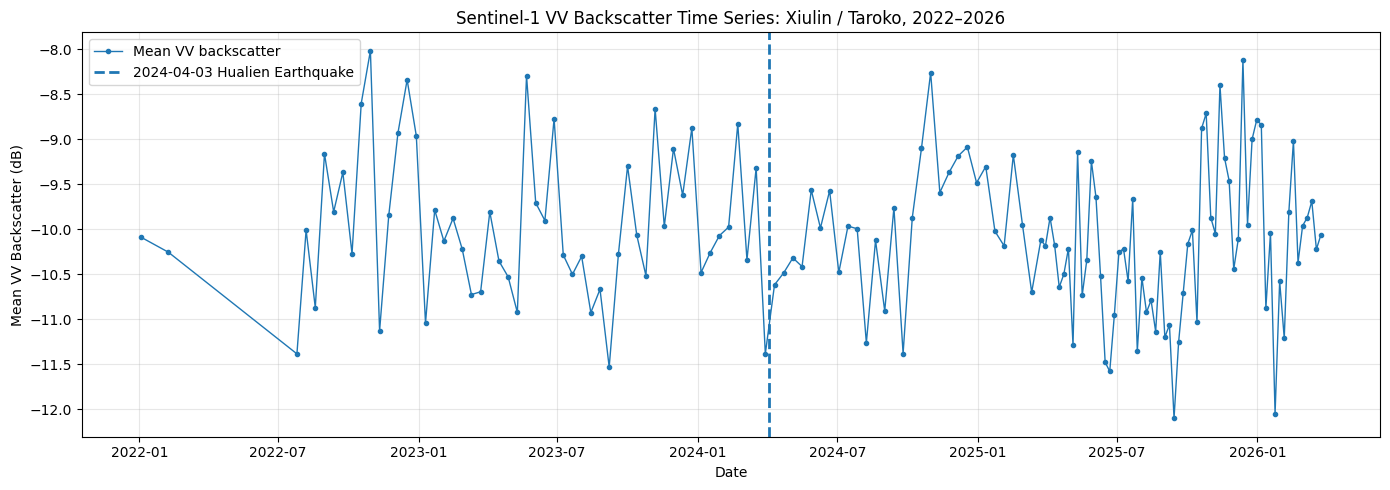

In [44]:
# 繪製 Sentinel-1 VV backscatter 時序圖

plt.figure(figsize=(14, 5))

plt.plot(
    s1_df["date"],
    s1_df["VV"],
    marker=".",
    linewidth=1,
    label="Mean VV backscatter"
)

# 標出 2024/04/03 花蓮地震
earthquake_date = pd.to_datetime("2024-04-03")
plt.axvline(
    earthquake_date,
    linestyle="--",
    linewidth=2,
    label="2024-04-03 Hualien Earthquake"
)

plt.title("Sentinel-1 VV Backscatter Time Series: Xiulin / Taroko, 2022–2026")
plt.xlabel("Date")
plt.ylabel("Mean VV Backscatter (dB)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

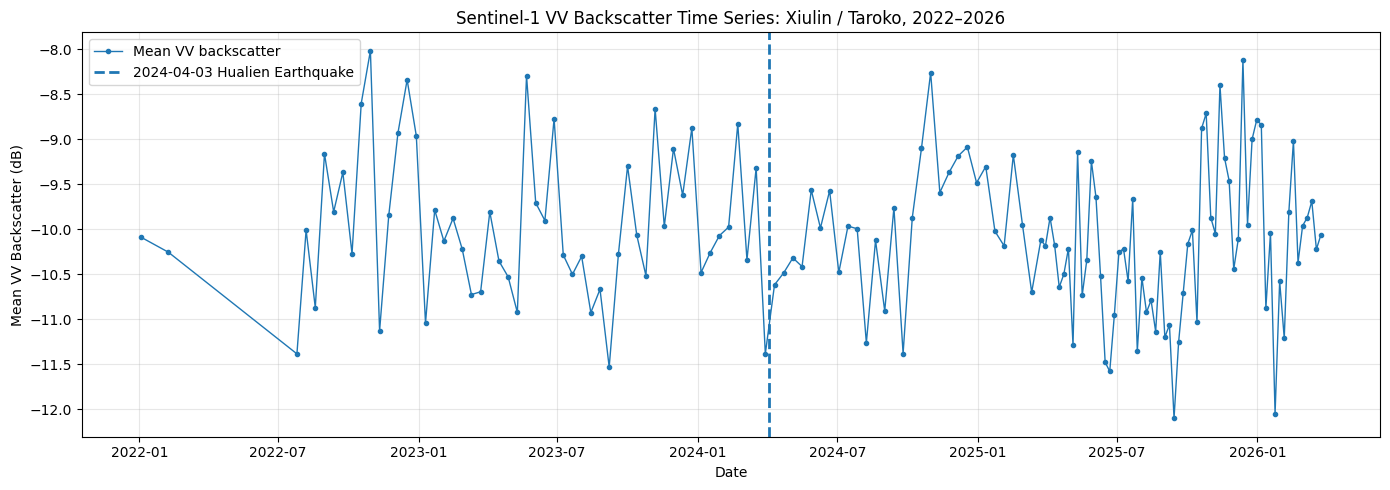

Saved figure: task3_sentinel1_vv_timeseries.png


In [45]:
# 儲存 Sentinel-1 VV 時序圖

plt.figure(figsize=(14, 5))

plt.plot(
    s1_df["date"],
    s1_df["VV"],
    marker=".",
    linewidth=1,
    label="Mean VV backscatter"
)

earthquake_date = pd.to_datetime("2024-04-03")
plt.axvline(
    earthquake_date,
    linestyle="--",
    linewidth=2,
    label="2024-04-03 Hualien Earthquake"
)

plt.title("Sentinel-1 VV Backscatter Time Series: Xiulin / Taroko, 2022–2026")
plt.xlabel("Date")
plt.ylabel("Mean VV Backscatter (dB)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("task3_sentinel1_vv_timeseries.png", dpi=300)
plt.show()

print("Saved figure: task3_sentinel1_vv_timeseries.png")

# Captain's log — Step 20：建立 Sentinel-1 VV Composite 與 ΔVV 變遷影像

本步驟的目標是建立 Sentinel-1 VV backscatter 的震前與震後 median composite，並計算 ΔVV 變遷影像。

Sentinel-1 SAR 可以提供與 Sentinel-2 NDVI 不同的觀測角度。NDVI 主要反映植被綠度，而 VV backscatter 可能受到地表粗糙度、裸露地、含水量與植被結構變化影響。因此，本步驟透過震前與震後 VV composite 的差值，觀察地震後研究區是否出現雷達散射訊號的空間變化。

In [46]:
# Task 3：建立 Sentinel-1 震前 / 震後 VV composite

# 震前 VV composite：2023-01 至 2024-03
pre_vv = (
    s1
    .filterDate("2023-01-01", "2024-03-31")
    .median()
    .rename("VV")
)

# 震後 VV composite：2024-04 至 2026-03
post_vv = (
    s1
    .filterDate("2024-04-01", "2026-03-31")
    .median()
    .rename("VV")
)

# ΔVV = 震後 VV - 震前 VV
delta_vv = post_vv.subtract(pre_vv).rename("delta_VV")

print("Sentinel-1 VV composites and delta_VV created successfully.")
print("pre_vv band names:", pre_vv.bandNames().getInfo())
print("post_vv band names:", post_vv.bandNames().getInfo())
print("delta_vv band names:", delta_vv.bandNames().getInfo())

Sentinel-1 VV composites and delta_VV created successfully.
pre_vv band names: ['VV']
post_vv band names: ['VV']
delta_vv band names: ['delta_VV']


# Captain's log — Step 20 檢查：統計震前與震後 Sentinel-1 影像數量

本步驟的目標是確認震前與震後 VV composite 分別使用多少張 Sentinel-1 影像。

影像數量會影響 median composite 的穩定性。若震前或震後影像數量太少，ΔVV 結果可能較容易受到單張影像雜訊影響。確認影像數量後，下一步會將 pre_vv、post_vv 與 delta_vv 顯示成地圖。

In [47]:
# 統計 Sentinel-1 震前與震後影像數量

pre_vv_count = s1.filterDate("2023-01-01", "2024-03-31").size().getInfo()
post_vv_count = s1.filterDate("2024-04-01", "2026-03-31").size().getInfo()

print("Number of Sentinel-1 images used:")
print(f"Pre-earthquake VV period  (2023-01 to 2024-03): {pre_vv_count}")
print(f"Post-earthquake VV period (2024-04 to 2026-03): {post_vv_count}")

Number of Sentinel-1 images used:
Pre-earthquake VV period  (2023-01 to 2024-03): 38
Post-earthquake VV period (2024-04 to 2026-03): 92


# Captain's log — Step 20 檢查：計算 AOI 平均 ΔVV

本步驟的目標是計算 ΔVV 在整個研究區內的平均值。

AOI 平均 ΔVV 可以提供整體趨勢，但 SAR 變化通常具有明顯空間差異，因此平均值可能會稀釋局部地表擾動。後續仍需要透過 ΔVV 地圖判斷哪些區域有較明顯的 backscatter 變化。

In [48]:
# 計算 AOI 內平均 ΔVV

mean_delta_vv = delta_vv.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=30,
    maxPixels=1e9,
    bestEffort=True
).get("delta_VV").getInfo()

print(f"Mean ΔVV over AOI: {mean_delta_vv:.4f} dB")

Mean ΔVV over AOI: -0.0335 dB


# Captain's log — Step 21：顯示 Sentinel-1 VV Composite 與 ΔVV 地圖

本步驟的目標是將 Sentinel-1 震前 VV composite、震後 VV composite 與 ΔVV 變遷影像顯示在互動式地圖上。

前一步計算的 AOI 平均 ΔVV 接近 0，代表整個研究區平均來看 SAR backscatter 沒有明顯整體變化。不過，地震或崩塌造成的地表擾動通常是局部發生，因此仍需要透過 ΔVV 地圖觀察空間分布。本步驟將以灰階顯示 VV composite，並以發散色階顯示 ΔVV，其中負值與正值分別代表震後雷達散射訊號下降或上升。

In [49]:
# Task 3：顯示 Sentinel-1 pre_vv、post_vv 與 delta_vv 地圖

# VV backscatter 視覺化參數
vv_vis = {
    "min": -25,
    "max": 0
}

# ΔVV 視覺化參數
# 藍色：VV 下降；白色：變化小；紅色：VV 上升
delta_vv_vis = {
    "min": -5,
    "max": 5,
    "palette": ["blue", "white", "red"]
}

Map = geemap.Map(center=[24.20, 121.60], zoom=10)

# 加入 AOI
Map.addLayer(aoi, {}, "AOI: Xiulin / Taroko")

# 加入震前與震後 VV composite
Map.addLayer(pre_vv.clip(aoi), vv_vis, "Sentinel-1 VV Pre-earthquake")
Map.addLayer(post_vv.clip(aoi), vv_vis, "Sentinel-1 VV Post-earthquake")

# 加入 ΔVV map
Map.addLayer(delta_vv.clip(aoi), delta_vv_vis, "ΔVV Post - Pre earthquake")

Map

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

# Captain's log — Step 22：建立 NDVI 與 SAR 高可信度變化區域

本步驟的目標是結合 Sentinel-2 NDVI 與 Sentinel-1 SAR 的變遷結果，建立高可信度地表變化區域。

單獨使用 NDVI 可能會受到雲、陰影、季節性植被變化或有效像素不足影響；單獨使用 SAR 則可能受到地表濕度、雷達入射角與地形效應影響。因此，本步驟使用多源資料交叉驗證的概念，將 ΔNDVI < -0.15 且 |ΔVV| > 2 dB 的區域標記為高可信度變化區域。若同一區域同時出現 NDVI 顯著下降與 SAR backscatter 明顯變化，代表該區域較可能發生真實的地表擾動。

In [50]:
# Task 3：建立 NDVI + SAR 高可信度變化區域遮罩
# 條件：ΔNDVI < -0.15 且 |ΔVV| > 2 dB

high_conf_change = (
    delta_eq.select("delta_NDVI_eq").lt(-0.15)
    .And(delta_vv.select("delta_VV").abs().gt(2))
    .rename("high_confidence_change")
)

high_conf_mask = high_conf_change.selfMask()

print("High-confidence change mask created successfully.")
print("Band names:", high_conf_change.bandNames().getInfo())

High-confidence change mask created successfully.
Band names: ['high_confidence_change']


# Captain's log — Step 22 檢查：計算高可信度變化區域面積

本步驟的目標是計算高可信度變化區域的面積。

此處的高可信度變化區域同時滿足兩個條件：第一，Sentinel-2 顯示 ΔNDVI < -0.15，代表植被明顯下降；第二，Sentinel-1 顯示 |ΔVV| > 2 dB，代表雷達散射訊號也有明顯變化。透過這種交叉比對，可以降低單一感測器造成誤判的機率。

In [51]:
# 計算高可信度變化區域面積，單位 hectares

area_high_conf_m2 = high_conf_change.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=aoi,
    scale=10,
    maxPixels=1e9,
    bestEffort=True
).get("high_confidence_change")

area_high_conf_ha = ee.Number(area_high_conf_m2).divide(10000).getInfo()

print(f"High-confidence change area: {area_high_conf_ha:.2f} ha")

High-confidence change area: 537.37 ha


# Captain's log — Step 22 地圖顯示：NDVI、SAR 與高可信度變化區域

本步驟的目標是將 NDVI 變化、SAR 變化與高可信度變化區域一起顯示在互動式地圖上。

地圖中會先顯示 ΔNDVI 與 ΔVV 的空間變化，再疊加高可信度變化區域遮罩。這可以幫助判斷哪些區域同時被光學與雷達資料偵測到明顯變化，作為後續 Task 3 分析中「多源資料交叉驗證」的主要依據。

In [52]:
# 顯示 NDVI、SAR 與高可信度變化區域

Map = geemap.Map(center=[24.20, 121.60], zoom=10)

Map.addLayer(aoi, {}, "AOI: Xiulin / Taroko")

# ΔNDVI：紅色代表植被下降，藍色代表植被增加
Map.addLayer(
    delta_eq.clip(aoi),
    {
        "min": -0.4,
        "max": 0.4,
        "palette": ["red", "white", "blue"]
    },
    "ΔNDVI Earthquake impact"
)

# ΔVV：藍色代表 VV 下降，紅色代表 VV 上升
Map.addLayer(
    delta_vv.clip(aoi),
    {
        "min": -5,
        "max": 5,
        "palette": ["blue", "white", "red"]
    },
    "ΔVV Post - Pre earthquake"
)

# 高可信度變化區域
Map.addLayer(
    high_conf_mask.clip(aoi),
    {"palette": ["magenta"]},
    "High-confidence change: ΔNDVI loss + SAR change"
)

Map

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

# Captain's log — Step 23：整理 Sentinel-1 SAR 與高可信度變化統計

本步驟的目標是整理 Task 3 的主要統計數值，包含震前 VV 平均值、震後 VV 平均值、平均 ΔVV，以及 NDVI + SAR 高可信度變化區域面積。

前面已經完成 Sentinel-1 VV 時序圖、ΔVV 地圖，以及 ΔNDVI < -0.15 且 |ΔVV| > 2 dB 的高可信度變化區域。本步驟將這些結果整理成表格，方便後續撰寫 Task 3 分析，並說明 SAR 變化與 NDVI 植被變化之間的關係。

In [53]:
# Task 3：整理 Sentinel-1 SAR 與高可信度變化統計

# 計算震前與震後 VV 平均值
mean_pre_vv = pre_vv.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=30,
    maxPixels=1e9,
    bestEffort=True
).get("VV").getInfo()

mean_post_vv = post_vv.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=30,
    maxPixels=1e9,
    bestEffort=True
).get("VV").getInfo()

# 整理成表格
task3_summary_df = pd.DataFrame({
    "item": [
        "Sentinel-1 pre-earthquake images",
        "Sentinel-1 post-earthquake images",
        "Mean pre-earthquake VV",
        "Mean post-earthquake VV",
        "Mean ΔVV over AOI",
        "High-confidence change area"
    ],
    "value": [
        pre_vv_count,
        post_vv_count,
        mean_pre_vv,
        mean_post_vv,
        mean_delta_vv,
        area_high_conf_ha
    ],
    "unit": [
        "images",
        "images",
        "dB",
        "dB",
        "dB",
        "ha"
    ]
})

task3_summary_df

,item,value,unit
0,Sentinel-1 pre-earthquake images,38.000000,images
1,Sentinel-1 post-earthquake images,92.000000,images
2,Mean pre-earthquake VV,-9.959353,dB
3,Mean post-earthquake VV,-9.992901,dB
4,Mean ΔVV over AOI,-0.033548,dB
5,High-confidence change area,537.374852,ha


# Captain's log — Step 24：Task 3 Sentinel-1 SAR 時序與交叉驗證分析

本步驟的目標是根據 Sentinel-1 VV 時序圖、ΔVV 地圖，以及 NDVI + SAR 高可信度變化區域，撰寫 Task 3 的分析說明。

前面已經建立 2022–2026 年 Sentinel-1 VV backscatter 時序，並比較震前與震後 VV median composite。接著也將 Sentinel-2 的 ΔNDVI 與 Sentinel-1 的 ΔVV 進行交叉比對，找出同時具有植被下降與雷達散射變化的高可信度地表變化區域。本步驟將這些結果整理成文字分析，說明 SAR 如何補充 NDVI 的限制。

## Task 3 分析：Sentinel-1 SAR VV 時序與 NDVI 交叉驗證

Sentinel-1 VV backscatter 時序顯示，秀林 / 太魯閣研究區在 2022–2026 年間具有明顯波動，但在整個 AOI 平均尺度下，地震前後的整體差異並不大。震前 VV composite 使用 38 張 Sentinel-1 影像，震後 VV composite 使用 92 張影像；震前平均 VV 為 -9.959 dB，震後平均 VV 為 -9.993 dB，平均 ΔVV 約為 -0.034 dB。這表示若只看整個研究區的平均值，SAR backscatter 並沒有明顯整體上升或下降。

然而，地震或崩塌造成的地表擾動通常是局部發生，因此平均值可能會稀釋局部變化。透過 ΔVV map 可以進一步觀察哪些區域的雷達散射訊號在震後有較明顯變化。當某區域同時滿足 ΔNDVI < -0.15 與 |ΔVV| > 2 dB 時，代表該區域同時被光學植被指標與 SAR 雷達訊號偵測到變化。本次分析得到的高可信度變化區域約為 537.37 ha，表示這些區域較可能是真實的地表擾動，而非單純由雲遮罩、季節性植被變化或單一感測器雜訊造成。

整體而言，Sentinel-1 SAR 可以補充 Sentinel-2 光學影像在多雲山區的限制。NDVI 適合判斷植被綠度下降，而 SAR 則能提供地表粗糙度、裸露地、含水量與結構變化的資訊。將兩者交叉比對後，可以提高災害變遷偵測的可信度，也延伸了 W10 單景 SAR 分析到 GEE 雲端時序分析的尺度。

# Captain's log — Step 25：匯出震後 NDVI Composite GeoTIFF

本步驟的目標是將震後 NDVI median composite 匯出為 GeoTIFF 檔案。

前面已經建立 2024-04 至 2024-09 的震後 NDVI composite，代表 2024/04/03 花蓮地震後短期的植被狀態。為了讓 GEE 的分析結果可以被後續本機流程或 W12 Random Forest 分類流程使用，本步驟會將 post_eq 影像匯出到 Google Drive。匯出完成後，需要到 Google Drive 的 GEE_Exports 資料夾確認檔案，並截圖作為作業交付證明。

In [54]:
# Task 4：匯出震後 NDVI composite 為 GeoTIFF

task_post_eq_ndvi = ee.batch.Export.image.toDrive(
    image=post_eq.clip(aoi),
    description="taroko_ndvi_post_eq_2024",
    folder="GEE_Exports",
    fileNamePrefix="taroko_ndvi_post_eq_2024",
    region=aoi,
    scale=10,
    crs="EPSG:32651",
    maxPixels=1e9
)

task_post_eq_ndvi.start()

print("Export task started: taroko_ndvi_post_eq_2024")
print("Please check Google Drive folder: GEE_Exports")

Export task started: taroko_ndvi_post_eq_2024
Please check Google Drive folder: GEE_Exports


In [55]:
# 檢查震後 NDVI GeoTIFF 匯出狀態

task_post_eq_ndvi.status()

{'state': 'RUNNING',
 'description': 'taroko_ndvi_post_eq_2024',
 'priority': 100,
 'creation_timestamp_ms': 1779730350354,
 'update_timestamp_ms': 1779730357582,
 'start_timestamp_ms': 1779730352127,
 'task_type': 'EXPORT_IMAGE',
 'attempt': 1,
 'id': 'PJ5MNNLVAR7RJ2VJZHC4GNAB',
 'name': 'projects/class-496807/operations/PJ5MNNLVAR7RJ2VJZHC4GNAB'}

# Captain's log — Step 26：匯出地震影響 ΔNDVI GeoTIFF

本步驟的目標是將地震前後的 ΔNDVI 變遷影像匯出為 GeoTIFF 檔案。

前面已經利用震後 NDVI composite 減去震前 NDVI composite，建立地震影響階段的 ΔNDVI 影像。ΔNDVI 可以表示地震後植被綠度的變化，其中負值代表 NDVI 下降，可能對應植被損失、山崩或裸露地增加。本步驟會將 delta_eq 匯出到 Google Drive，作為後續本機分析、W12 Random Forest 分類或作業交付成果使用。

In [56]:
# Task 4：匯出地震影響 ΔNDVI 為 GeoTIFF

task_delta_ndvi_eq = ee.batch.Export.image.toDrive(
    image=delta_eq.clip(aoi),
    description="taroko_delta_ndvi_eq_2024",
    folder="GEE_Exports",
    fileNamePrefix="taroko_delta_ndvi_eq_2024",
    region=aoi,
    scale=10,
    crs="EPSG:32651",
    maxPixels=1e9
)

task_delta_ndvi_eq.start()

print("Export task started: taroko_delta_ndvi_eq_2024")
print("Please check Google Drive folder: GEE_Exports")

Export task started: taroko_delta_ndvi_eq_2024
Please check Google Drive folder: GEE_Exports


In [57]:
# 檢查 ΔNDVI GeoTIFF 匯出狀態

task_delta_ndvi_eq.status()

{'state': 'RUNNING',
 'description': 'taroko_delta_ndvi_eq_2024',
 'priority': 100,
 'creation_timestamp_ms': 1779730429920,
 'update_timestamp_ms': 1779730432923,
 'start_timestamp_ms': 1779730432865,
 'task_type': 'EXPORT_IMAGE',
 'attempt': 1,
 'id': 'RLM3SYKMB2W6HXRXFHSWUILH',
 'name': 'projects/class-496807/operations/RLM3SYKMB2W6HXRXFHSWUILH'}

# Captain's log — Step 27：整理資料規模與本機下載時間估算

本步驟的目標是整理本次 GEE 分析處理的資料規模，並估算若改成本機下載處理所需的時間。

Task 4 的整合摘要需要比較 GEE 雲端處理與本機處理的差異。因此本步驟會統計 Sentinel-2 與 Sentinel-1 使用的影像數量，並以每張 Sentinel-2 影像約 800 MB、網路速度 50 Mbps 為假設，估算若將 Sentinel-2 影像全部下載到本機需要多久。這可以用來說明 GEE 在大規模時序分析中的效率優勢。

In [58]:
# Task 4：整理資料規模與下載時間估算

# 已處理影像數量
sentinel2_count = s2.size().getInfo()
sentinel1_count = s1.size().getInfo()

# 假設每張 Sentinel-2 影像約 800 MB
s2_image_size_mb = 800
total_s2_size_mb = sentinel2_count * s2_image_size_mb
total_s2_size_gb = total_s2_size_mb / 1024

# 假設網路速度為 50 Mbps
# 50 Mbps = 50 / 8 = 6.25 MB/s
download_speed_mbps = 50
download_speed_MBps = download_speed_mbps / 8

download_time_seconds = total_s2_size_mb / download_speed_MBps
download_time_hours = download_time_seconds / 3600

print("Task 4 Data Scale Summary")
print("-------------------------")
print(f"Sentinel-2 images processed: {sentinel2_count}")
print(f"Sentinel-1 images processed: {sentinel1_count}")
print()
print(f"Assumed Sentinel-2 image size: {s2_image_size_mb} MB/image")
print(f"Total Sentinel-2 data size: {total_s2_size_mb:,.0f} MB ({total_s2_size_gb:.2f} GB)")
print(f"Assumed download speed: {download_speed_mbps} Mbps ({download_speed_MBps:.2f} MB/s)")
print(f"Estimated Sentinel-2 download time: {download_time_hours:.2f} hours")

Task 4 Data Scale Summary
-------------------------
Sentinel-2 images processed: 291
Sentinel-1 images processed: 146

Assumed Sentinel-2 image size: 800 MB/image
Total Sentinel-2 data size: 232,800 MB (227.34 GB)
Assumed download speed: 50 Mbps (6.25 MB/s)
Estimated Sentinel-2 download time: 10.35 hours


# Captain's log — Step 27 檢查：確認 GeoTIFF 匯出任務狀態

本步驟的目標是再次確認兩個 GeoTIFF 匯出任務的執行狀態。

GEE 的 Export 任務是非同步執行，因此送出任務後不一定會立即完成。此處重新檢查震後 NDVI composite 與地震影響 ΔNDVI GeoTIFF 的匯出狀態。若狀態為 RUNNING，表示仍在匯出；若為 COMPLETED，表示可以到 Google Drive 的 GEE_Exports 資料夾確認檔案並截圖。

In [59]:
# 檢查兩個 GeoTIFF 匯出任務狀態

print("Post-earthquake NDVI export status:")
print(task_post_eq_ndvi.status())

print("\nDelta NDVI export status:")
print(task_delta_ndvi_eq.status())

Post-earthquake NDVI export status:
{'state': 'RUNNING', 'description': 'taroko_ndvi_post_eq_2024', 'priority': 100, 'creation_timestamp_ms': 1779730350354, 'update_timestamp_ms': 1779730514924, 'start_timestamp_ms': 1779730352127, 'task_type': 'EXPORT_IMAGE', 'attempt': 1, 'batch_eecu_usage_seconds': 83.195, 'id': 'PJ5MNNLVAR7RJ2VJZHC4GNAB', 'name': 'projects/class-496807/operations/PJ5MNNLVAR7RJ2VJZHC4GNAB'}

Delta NDVI export status:
{'state': 'RUNNING', 'description': 'taroko_delta_ndvi_eq_2024', 'priority': 100, 'creation_timestamp_ms': 1779730429920, 'update_timestamp_ms': 1779730491614, 'start_timestamp_ms': 1779730432865, 'task_type': 'EXPORT_IMAGE', 'attempt': 1, 'id': 'RLM3SYKMB2W6HXRXFHSWUILH', 'name': 'projects/class-496807/operations/RLM3SYKMB2W6HXRXFHSWUILH'}


## Task 4 Integration Summary

本次作業將 ARIA 系統升級為 v9.0 — The Cloud Engine，使用 Google Earth Engine 對秀林 / 太魯閣研究區進行雲端時序分析。本次共處理 291 張 Sentinel-2 影像與 146 張 Sentinel-1 影像。若以每張 Sentinel-2 影像約 800 MB 估算，總資料量約為 227.34 GB；若使用 50 Mbps 網路下載，僅 Sentinel-2 影像就約需 10.35 小時，尚未包含本機前處理、雲遮罩與統計分析時間。因此，GEE 能直接在雲端處理 ImageCollection，對多年度災害時序分析具有明顯效率優勢。

在 Sentinel-2 NDVI 分析中，2020–2026 年月平均 NDVI 顯示研究區具有明顯時間波動。地震前 2023-01 至 2024-03 的平均 NDVI 為 0.485，地震後短期 2024-04 至 2024-09 為 0.481，地震後長期 2024-10 至 2026-03 為 0.479，整體平均下降幅度不大。然而，2024-10 出現最低 NDVI 0.209，顯示局部災害、有效像素不足或季節性因素可能造成顯著低值。三期 ΔNDVI 分析中，ΔNDVI < -0.15 的地震影響面積為 7740.15 ha，堰塞湖後變化面積為 6257.68 ha，整體累積下降面積為 6839.04 ha。

Sentinel-1 SAR 分析提供了另一個觀測角度。震前平均 VV 為 -9.959 dB，震後平均 VV 為 -9.993 dB，平均 ΔVV 約為 -0.034 dB，表示整個 AOI 平均尺度下 SAR backscatter 沒有明顯整體變化。不過，結合 ΔNDVI < -0.15 與 |ΔVV| > 2 dB 後，可得到約 537.37 ha 的高可信度變化區域，代表這些區域同時被光學與雷達資料偵測到地表變化。

相較於 W8 的單景 NDVI，W13 的 GEE 時序分析可以觀察長期趨勢；相較於 W9 的兩張單景差值，median composite 可降低雲、陰影與單景異常值影響；相較於 W10 的單景 SAR，Sentinel-1 時序能提供更穩定的災害監測脈絡。匯出的 post-earthquake NDVI composite 與 ΔNDVI GeoTIFF 也可作為 W12 Random Forest 分類的額外特徵。然而，若需要高度客製化演算法、深度學習模型訓練、特殊資料格式或精細本機除錯，STAC API 加本機處理仍然有其必要性。

In [60]:
# 再次檢查兩個 GeoTIFF 匯出任務狀態

print("Post-earthquake NDVI export status:")
print(task_post_eq_ndvi.status())

print("\nDelta NDVI export status:")
print(task_delta_ndvi_eq.status())

Post-earthquake NDVI export status:
{'state': 'RUNNING', 'description': 'taroko_ndvi_post_eq_2024', 'priority': 100, 'creation_timestamp_ms': 1779730350354, 'update_timestamp_ms': 1779730594920, 'start_timestamp_ms': 1779730352127, 'task_type': 'EXPORT_IMAGE', 'attempt': 1, 'batch_eecu_usage_seconds': 117.168, 'id': 'PJ5MNNLVAR7RJ2VJZHC4GNAB', 'name': 'projects/class-496807/operations/PJ5MNNLVAR7RJ2VJZHC4GNAB'}

Delta NDVI export status:
{'state': 'RUNNING', 'description': 'taroko_delta_ndvi_eq_2024', 'priority': 100, 'creation_timestamp_ms': 1779730429920, 'update_timestamp_ms': 1779730582628, 'start_timestamp_ms': 1779730432865, 'task_type': 'EXPORT_IMAGE', 'attempt': 1, 'id': 'RLM3SYKMB2W6HXRXFHSWUILH', 'name': 'projects/class-496807/operations/RLM3SYKMB2W6HXRXFHSWUILH'}


# Captain's log — Step 29：撰寫雲端時序分析心得

本步驟的目標是撰寫本次作業的簡短心得，說明從單景分析進入雲端時序分析後，分析思維上的改變，以及 Google Earth Engine 在防災應用中的價值。

前面的 W8–W12 分析較偏向單張影像或少數影像的快照式判讀，而本次 ARIA v9.0 則使用多年度 ImageCollection 建立時間序列，能夠從時間軸上觀察災害前後的變化脈絡。這種方法不只可以看見某一個時間點的狀態，也可以追蹤地震、堰塞湖事件與後續恢復之間的關係。

## 簡短心得

從單景分析進入雲端時序分析後，我認為最大的改變是分析重點從「某一張影像顯示什麼」轉變為「一段時間內的變化趨勢是什麼」。在 W8–W12 中，分析結果容易受到單張影像的雲、陰影或拍攝時間影響；但在 GEE 中，可以利用多張影像建立 monthly time series 與 median composite，使結果更穩定。對防災應用而言，GEE 的價值在於能快速處理大量 Sentinel-2 與 Sentinel-1 影像，追蹤地震前後、堰塞湖事件與後續恢復的變化，讓災害監測從單一快照變成完整時間線。

In [63]:
# 檢查兩個 GeoTIFF 匯出任務狀態

print("Post-earthquake NDVI export status:")
print(task_post_eq_ndvi.status())

print("\nDelta NDVI export status:")
print(task_delta_ndvi_eq.status())

Post-earthquake NDVI export status:
{'state': 'RUNNING', 'description': 'taroko_ndvi_post_eq_2024', 'priority': 100, 'creation_timestamp_ms': 1779730350354, 'update_timestamp_ms': 1779731154924, 'start_timestamp_ms': 1779730352127, 'task_type': 'EXPORT_IMAGE', 'attempt': 1, 'batch_eecu_usage_seconds': 241.458, 'id': 'PJ5MNNLVAR7RJ2VJZHC4GNAB', 'name': 'projects/class-496807/operations/PJ5MNNLVAR7RJ2VJZHC4GNAB'}

Delta NDVI export status:
{'state': 'RUNNING', 'description': 'taroko_delta_ndvi_eq_2024', 'priority': 100, 'creation_timestamp_ms': 1779730429920, 'update_timestamp_ms': 1779731162640, 'start_timestamp_ms': 1779730432865, 'task_type': 'EXPORT_IMAGE', 'attempt': 1, 'batch_eecu_usage_seconds': 378.694, 'id': 'RLM3SYKMB2W6HXRXFHSWUILH', 'name': 'projects/class-496807/operations/RLM3SYKMB2W6HXRXFHSWUILH'}
